In [ ]:
# Mount Drive & set paths
from google.colab import drive
drive.mount('/content/drive')

import os

# Path to your generated dataset
DATASET_PATH = "/content/drive/MyDrive/Synthetic_Glasses_Dataset_Train"
OUTPUT_DIR = "/content/drive/MyDrive/glasses_removal_lora"

# Verify data exists
with_dir = os.path.join(DATASET_PATH, "source_with_glasses")
without_dir = os.path.join(DATASET_PATH, "target_no_glasses")
num_pairs = len(os.listdir(with_dir))
print(f"Found {num_pairs} pairs")

Mounted at /content/drive
Found 494 pairs


In [ ]:
# Install dependencies
!pip install -q diffusers[training] accelerate transformers datasets peft bitsandbytes xformers
!pip install -q wandb  # optional, for logging

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 18.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.


In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Prepare dataset in HuggingFace format
# The training script expects a HF Dataset with columns:
#   - original_image (PIL Image) — the input (with glasses)
#   - edited_image (PIL Image) — the target (no glasses)
#   - edit_prompt (str) — the editing instruction
#
# We'll create this from our folder structure and push to a local dataset.

import json
from PIL import Image
from datasets import Dataset, Features, Value, Image as HFImage

with_dir = os.path.join(DATASET_PATH, "source_with_glasses")
without_dir = os.path.join(DATASET_PATH, "target_no_glasses")

filenames = sorted([f for f in os.listdir(with_dir) if f.endswith(".png")])

records = []
for fname in filenames:
    with_path = os.path.join(with_dir, fname)
    without_path = os.path.join(without_dir, fname)

    if not os.path.exists(without_path):
        continue

    records.append({
        "original_image": with_path,
        "edited_image": without_path,
        "edit_prompt": "Remove the glasses from this person's face",
    })

print(f"Prepared {len(records)} training examples")

# Create HF Dataset
dataset = Dataset.from_dict({
    "original_image": [r["original_image"] for r in records],
    "edited_image": [r["edited_image"] for r in records],
    "edit_prompt": [r["edit_prompt"] for r in records],
})

# Cast image columns so HF loads them as PIL Images
dataset = dataset.cast_column("original_image", HFImage())
dataset = dataset.cast_column("edited_image", HFImage())

# Save to disk for the training script
HF_DATASET_PATH = "/content/glasses_dataset_hf"
dataset.save_to_disk(HF_DATASET_PATH)

print(f"Dataset saved to {HF_DATASET_PATH}")
print(dataset)

dataset.push_to_hub("brandonwooding/glasses-removal-dataset", private=True)
HF_DATASET_ID = "brandonwooding/glasses-removal-dataset"

Prepared 494 training examples


Saving the dataset (0/4 shards):   0%|          | 0/494 [00:00<?, ? examples/s]

Dataset saved to /content/glasses_dataset_hf
Dataset({
    features: ['original_image', 'edited_image', 'edit_prompt'],
    num_rows: 494
})


Uploading the dataset shards:   0%|          | 0/4 [00:00<?, ? shards/s]

Map:   0%|          | 0/124 [00:00<?, ? examples/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   9%|8         | 33.4MB /  393MB            

README.md:   0%|          | 0.00/375 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


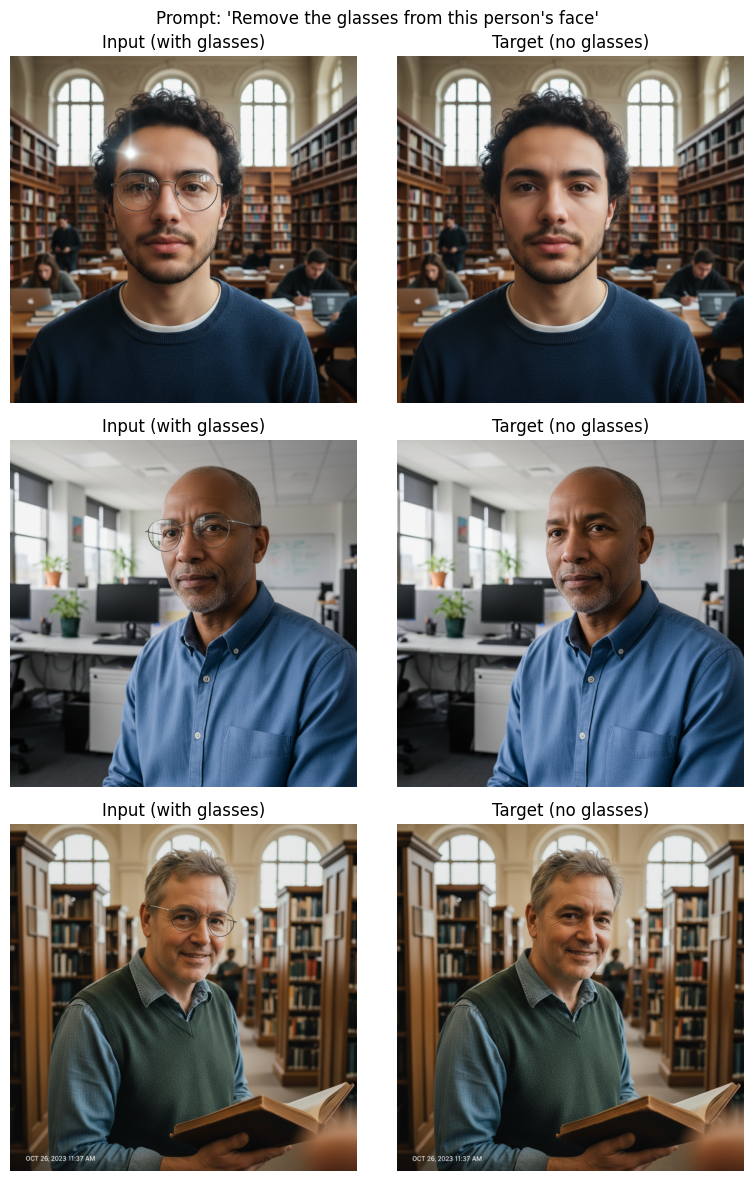

In [ ]:
# Sanity check — visualize a few examples
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
samples = random.sample(range(len(dataset)), 3)

for row, idx in enumerate(samples):
    example = dataset[idx]
    axes[row][0].imshow(example["original_image"])
    axes[row][0].set_title("Input (with glasses)")
    axes[row][0].axis("off")

    axes[row][1].imshow(example["edited_image"])
    axes[row][1].set_title("Target (no glasses)")
    axes[row][1].axis("off")

plt.suptitle(f"Prompt: '{dataset[0]['edit_prompt']}'")
plt.tight_layout()
plt.show()

In [ ]:
# Configure accelerate (required for the training script)
import subprocess

accelerate_config = """
compute_environment: LOCAL_MACHINE
debug: false
distributed_type: 'NO'
downcast_bf16: 'no'
gpu_ids: '0'
machine_rank: 0
mixed_precision: fp16
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
tpu_env: []
tpu_use_cluster: false
tpu_use_sudo: false
use_cpu: false
""".strip()

os.makedirs(os.path.expanduser("~/.cache/huggingface/accelerate"), exist_ok=True)
with open(os.path.expanduser("~/.cache/huggingface/accelerate/default_config.yaml"), "w") as f:
    f.write(accelerate_config)

print("Accelerate configured for single GPU fp16 training")

Accelerate configured for single GPU fp16 training


In [ ]:
# Download the training script from diffusers
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/main/examples/instruct_pix2pix/train_instruct_pix2pix.py
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/main/examples/instruct_pix2pix/requirements.txt
!pip install -q -r requirements.txt
!pip install -q git+https://github.com/huggingface/diffusers.git

print("Training script downloaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Training script downloaded


In [ ]:
# Patch the training script to skip conv_in expansion
# since timbrooks/instruct-pix2pix already has 8 input channels

with open("train_instruct_pix2pix.py", "r") as f:
    script = f.read()

# The script tries to create a new 8-channel conv_in and copy weights from a 4-channel one.
# Since our model already has 8 channels, we skip this entire block.
old_code = """    in_channels = 8
    out_channels = unet.conv_in.out_channels
    unet.register_to_config(in_channels=in_channels)

    with torch.no_grad():
        new_conv_in = nn.Conv2d(
            in_channels, out_channels, unet.conv_in.kernel_size, unet.conv_in.stride, unet.conv_in.padding
        )
        new_conv_in.weight.zero_()
        new_conv_in.weight[:, :4, :, :].copy_(unet.conv_in.weight)
        unet.conv_in = new_conv_in"""

if old_code in script:
    patched = script.replace(old_code, "    # PATCHED: skipping conv_in expansion (already 8 channels)")
    with open("train_instruct_pix2pix.py", "w") as f:
        f.write(patched)
    print("Successfully patched training script")
else:
    print("WARNING: Could not find the conv_in expansion code to patch.")
    print("The script may have changed. Check manually around line 520.")

Successfully patched training script


In [ ]:
# Launch training
#
# Key settings for T4 (16GB VRAM):
#   - resolution=512 (SD 1.5 native)
#   - train_batch_size=1 (T4 is tight)
#   - gradient_accumulation_steps=4 (effective batch size of 4)
#   - gradient_checkpointing (saves VRAM at cost of speed)
#   - use_8bit_adam (saves VRAM)
#   - mixed_precision=fp16

MODEL_NAME = "timbrooks/instruct-pix2pix"

!accelerate launch train_instruct_pix2pix.py \
    --pretrained_model_name_or_path={MODEL_NAME} \
    --dataset_name={HF_DATASET_ID} \
    --original_image_column="original_image" \
    --edited_image_column="edited_image" \
    --edit_prompt_column="edit_prompt" \
    --output_dir={OUTPUT_DIR} \
    --resolution=512 \
    --train_batch_size=4 \
    --gradient_accumulation_steps=1 \
    --gradient_checkpointing \
    --use_8bit_adam \
    --max_train_steps=5000 \
    --checkpointing_steps=1000 \
    --checkpoints_total_limit=2 \
    --learning_rate=1e-04 \
    --lr_scheduler="constant" \
    --lr_warmup_steps=0 \
    --conditioning_dropout_prob=0.05 \
    --max_grad_norm=1 \
    --mixed_precision=fp16 \
    --enable_xformers_memory_efficient_attention \
    --seed=42 \
    --push_to_hub

Streaming output truncated to the last 5000 lines.



  ...pytorch_model.safetensors: 100% 3.43G/3.44G [02:17<00:00, 24.9MB/s]




  ...pytorch_model.safetensors:  96% 3.28G/3.44G [02:17<00:06, 23.8MB/s]





  ...-4000/random_states_0.pkl:  51% 7.54k/14.8k [02:17<-00:01, -3.79kB/s]






  ...-5000/random_states_0.pkl:  51% 7.54k/14.8k [02:17<02:43, 44.7B/s]







  ...6986.144101fa1784.15777.1:  51% 1.25k/2.45k [02:17<-00:00, -4.01kB/s]








  ...24032.4a3ab375e7d4.8940.1:  51% 1.28k/2.52k [02:17<-00:00, -4.01kB/s]









  ...4217.4a3ab375e7d4.10104.1:  51% 1.25k/2.45k [02:17<-00:00, -3.03kB/s]










Processing Files (8 / 19)     :  99% 15.3G/15.4G [02:20<00:02, 62.4MB/s, 76.3MB/s  ]
New Data Upload               :  99% 11.3G/11.5G [02:20<00:02, 62.3MB/s, 76.3MB/s  ]

  ...kpoint-5000/optimizer.bin: 100% 1.75G/1.75G [02:19<00:00, 12.5MB/s]


  ...kpoint-4000/optimizer.bin: 100% 1.75G/1.75G [02:18<00:00, 12.6MB/s]



  ...pytorch_model.safetensors: 100% 3.43G/3.44G [02:18<0

In [ ]:
import os
checkpoint_path = "/content/drive/MyDrive/glasses_removal_lora/checkpoint-2000"
for root, dirs, files in os.walk(checkpoint_path):
    level = root.replace(checkpoint_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        size = os.path.getsize(os.path.join(root, file))
        print(f'{subindent}{file} ({size/1e6:.1f} MB)')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

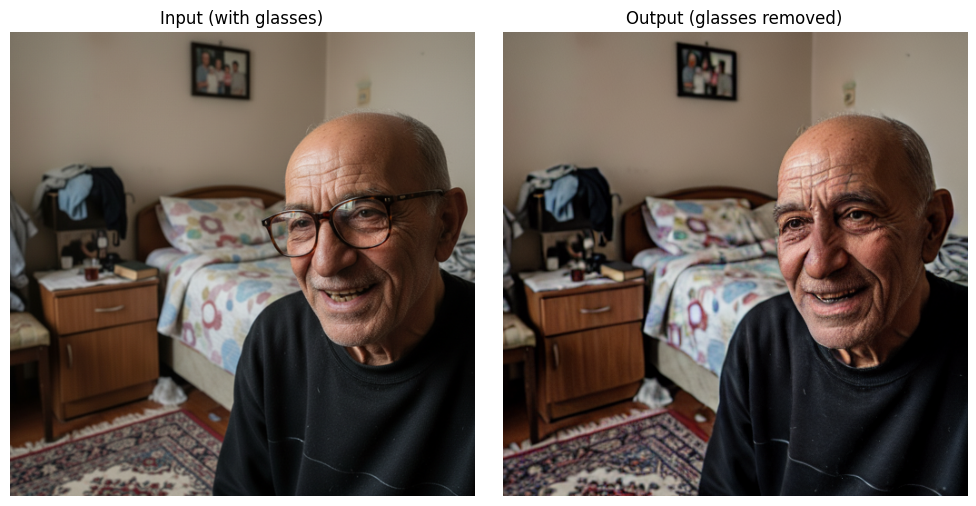

In [ ]:
# Mini-test the fine-tuned model
import torch
from diffusers import StableDiffusionInstructPix2PixPipeline
from diffusers.utils import load_image
from PIL import Image

# Load the fine-tuned model
pipe_ft = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    OUTPUT_DIR,
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")

# Test on a sample
test_image_path = os.path.join(with_dir, sorted(os.listdir(with_dir))[0])
test_image = load_image(test_image_path).resize((512, 512))

result = pipe_ft(
    prompt="Remove the glasses from this person's face",
    image=test_image,
    guidance_scale=7.5,
    image_guidance_scale=1.5,
    num_inference_steps=50,
).images[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test_image)
axes[0].set_title("Input (with glasses)")
axes[0].axis("off")
axes[1].imshow(result)
axes[1].set_title("Output (glasses removed)")
axes[1].axis("off")
plt.tight_layout()
plt.show()